In [1]:
def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 26
bound = 5
output = elliptic_fourier_expansions(level, bound)
print(len(output))
print()
print(output)
print()
print(output[1])
print()
print(output[1][1])

2

[('26a1', [(1, 1), (2, -1), (3, 1), (4, 1), (5, -3)]), ('26b1', [(1, 1), (2, 1), (3, -3), (4, 1), (5, -1)])]

('26b1', [(1, 1), (2, 1), (3, -3), (4, 1), (5, -1)])

[(1, 1), (2, 1), (3, -3), (4, 1), (5, -1)]


In [1]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 26
bound =2800
output = elliptic_fourier_expansions(level, bound)
data=output[1]
label = data[0]
expansion=data[1]
print("label:", label)
coeffs_list=[pair[1] for pair in expansion]

    
h_list=[1]+coeffs_list # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,501):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    print((n,j_n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run26mar26no1.txt', 'wb') as wfile:
    pickle.dump(expansion, wfile) 
    
with open('/Users/barrybrent/data2/run26mar26no2.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

label: 26b1
(1, 1)
(2, 1)
(3, -11)
(4, 17)
(5, -9)
(6, -59)
(7, 141)
(8, -127)
(9, -146)
(10, 791)
(11, -1286)
(12, 173)
(13, 3875)
(14, -9239)
(15, 7899)
(16, 13281)
(17, -56371)
(18, 81886)
(19, 5226)
(20, -285393)
(21, 623325)
(22, -443090)
(23, -1093396)
(24, 3936701)
(25, -5171484)
(26, -1576561)
(27, 20852575)
(28, -41512335)
(29, 23322410)
(30, 86664731)
(31, -272545024)
(32, 321357729)
(33, 191494534)
(34, -1505677691)
(35, 2737249471)
(36, -1100374810)
(37, -6696069893)
(38, 18708960566)
(39, -19558698469)
(40, -18757279617)
(41, 107575568720)
(42, -178572549515)
(43, 40486145611)
(44, 507069283166)
(45, -1273317706686)
(46, 1159248695900)
(47, 1662316990953)
(48, -7611390489123)
(49, 11512472865370)
(50, -346498836684)
(51, -37769572261951)
(52, 85907277901423)
(53, -66294841875836)
(54, -138890176893905)
(55, 533614847904954)
(56, -732277305698751)
(57, -143616087944850)
(58, 2774118119469986)
(59, -5743679099276542)
(60, 3599087827286163)
(61, 11155868417189120)
(62, -37082

1 9.321371714274088e-05
2 0.001268478234608968
3 0.00175018310546875
4 0.0018743793169657388
5 0.0019485831260681152
6 0.00202031135559082
7 0.0020676970481872557
8 0.002134227752685547
9 0.002201978365580241
10 0.002272045612335205
11 0.002358897527058919
12 0.0024527470270792645
13 0.0025896668434143067
14 0.002696533997853597
15 0.002829281489054362
16 0.002979429562886556
17 0.003138860066731771
18 0.003312095006306966
19 0.003509378433227539
20 0.003746143976847331
21 0.004005062580108643
22 0.004248178005218506
23 0.004534514745076498
24 0.004801547527313233
25 0.005082082748413086
26 0.005455660820007324
27 0.0058621644973754885
28 0.0062782605489095054
29 0.00674291451772054
30 0.00720377763112386
31 0.007658179601033529
32 0.008149047692616781
33 0.008685298760732015
34 0.009286864598592123
35 0.01002121369043986
36 0.010770662625630697
37 0.011617414156595866
38 0.012509799003601075
39 0.01349794864654541
40 0.014421149094899496
41 0.015302515029907227
42 0.016312062740325928

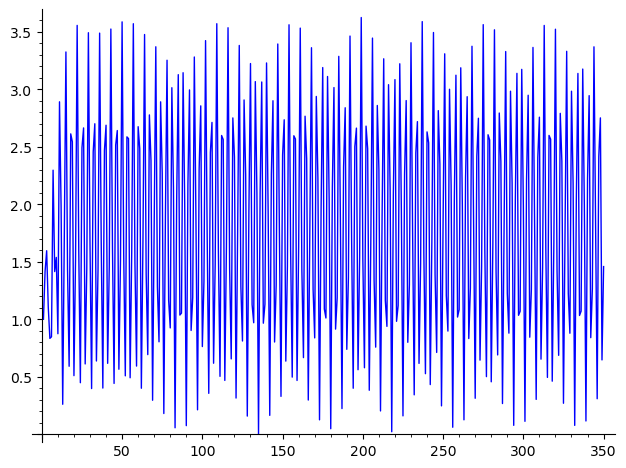

In [2]:
import pickle
from sage.all import sigma, nth_prime
import ast
import time

start=time.time()
with open('/Users/barrybrent/data2/run26mar26no2.txt', 'rb') as rfile:
    j_list = pickle.load(rfile)
    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    print(n, (time.time()-start)/60)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run26mar26no3.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run26mar26no4.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run26mar26no5.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped
